In [38]:
import cv2
import numpy as np
from ultralytics import YOLO
import matplotlib.pyplot as plt

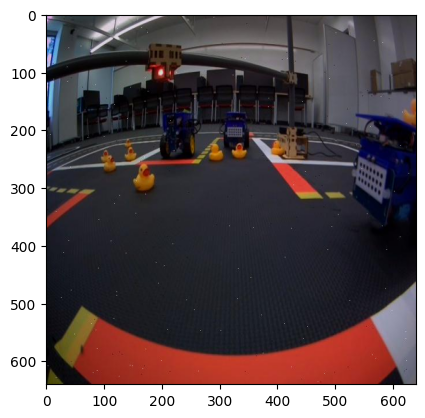

In [39]:
img = cv2.imread('test_duckies.jpg')
#img = cv2.imread('test_duckies_2.png')
img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
plt.imshow(img)

In [40]:
model = YOLO("/home/duckie5/Downloads/Duckiebtown_DB21J.v5i (1).yolov11/trained_model1.pt") 

In [41]:
# Train the model
#results = model.train(data="/home/duckie5/Downloads/Duckiebtown_DB21J.v5i.yolov11/data.yaml", epochs=100, imgsz=640)

In [42]:
def draw_bounding_boxes(results,img):
    for result in results:
        for box in result.boxes:
            cv2.rectangle(img, (int(box.xyxy[0][0]), int(box.xyxy[0][1])),
                          (int(box.xyxy[0][2]), int(box.xyxy[0][3])), (255, 0, 0), 5)
            cv2.putText(img, f"{result.names[int(box.cls[0])]}",
                        (int(box.xyxy[0][0]), int(box.xyxy[0][1]) - 10),
                        cv2.FONT_HERSHEY_PLAIN, 1, (255, 0, 0), 5)
    return img



0: 640x640 1 duckie, 7 duckiebots, 261.5ms
Speed: 4.1ms preprocess, 261.5ms inference, 0.4ms postprocess per image at shape (1, 3, 640, 640)
[ultralytics.engine.results.Results object with attributes:

boxes: ultralytics.engine.results.Boxes object
keypoints: None
masks: None
names: {0: 'duckie', 1: 'duckiebot'}
obb: None
orig_img: array([[[150, 169, 201],
        [125, 135, 170],
        [136, 127, 170],
        ...,
        [ 61,  61,  63],
        [ 61,  61,  63],
        [ 61,  61,  63]],

       [[115, 131, 164],
        [114, 122, 158],
        [143, 134, 177],
        ...,
        [ 61,  61,  63],
        [ 61,  61,  63],
        [ 61,  61,  63]],

       [[100, 115, 148],
        [125, 131, 167],
        [166, 155, 198],
        ...,
        [ 62,  62,  64],
        [ 62,  62,  64],
        [ 62,  62,  64]],

       ...,

       [[  8,  13,   0],
        [ 12,  17,   0],
        [ 38,  41,  12],
        ...,
        [104,  99, 105],
        [104,  99, 103],
        [103,  98, 

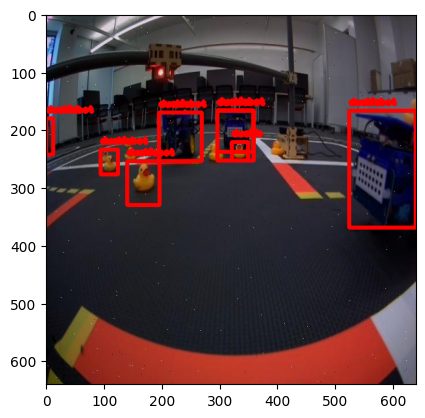

In [43]:
results = model(img)
result_img = draw_bounding_boxes(results,img)
plt.imshow(result_img)
print(results)

In [44]:
results[0].boxes

ultralytics.engine.results.Boxes object with attributes:

cls: tensor([1., 1., 1., 1., 1., 0., 1., 1.])
conf: tensor([0.6505, 0.4444, 0.3999, 0.3640, 0.3599, 0.3109, 0.2759, 0.2650])
data: tensor([[1.9505e+02, 1.7001e+02, 2.6916e+02, 2.5403e+02, 6.5049e-01, 1.0000e+00],
        [5.2492e+02, 1.6770e+02, 6.3949e+02, 3.6935e+02, 4.4444e-01, 1.0000e+00],
        [9.4041e+01, 2.3404e+02, 1.2476e+02, 2.7731e+02, 3.9990e-01, 1.0000e+00],
        [2.9615e+02, 1.6704e+02, 3.5990e+02, 2.5337e+02, 3.6398e-01, 1.0000e+00],
        [2.9678e+02, 1.6684e+02, 3.5896e+02, 2.3887e+02, 3.5991e-01, 1.0000e+00],
        [3.2125e+02, 2.2145e+02, 3.4936e+02, 2.5337e+02, 3.1088e-01, 0.0000e+00],
        [1.3140e-01, 1.8010e+02, 1.2516e+01, 2.4370e+02, 2.7589e-01, 1.0000e+00],
        [1.4059e+02, 2.5469e+02, 1.9673e+02, 3.3032e+02, 2.6498e-01, 1.0000e+00]])
id: None
is_track: False
orig_shape: (640, 640)
shape: torch.Size([8, 6])
xywh: tensor([[232.1067, 212.0189,  74.1049,  84.0135],
        [582.2076, 268.5

In [45]:
# reshape into 3 arrays: x[], y[], class[]

In [46]:
#check results if duckie in area : parking, intersecrtion, overtaking